### Imports

In [1]:
import pandas as pd
import numpy as np
import optuna
import mlflow
import mlflow.sklearn
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

### Load Data

In [2]:
df = pd.read_csv('D:/Projects/predictiq/data/master_features.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

split_date = pd.Timestamp('2015-10-01')
train = df[df['datetime'] < split_date]
test  = df[df['datetime'] >= split_date]

feature_cols = [c for c in df.columns if c not in ['datetime', 'machineID', 'label']]

X_train = train[feature_cols]
y_train = train['label']
X_test  = test[feature_cols]
y_test  = test['label']

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"Data loaded. Scale pos weight: {scale:.1f}")

Data loaded. Scale pos weight: 48.8


### Define Optuna Objective

In [3]:
def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 150),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': scale,
        'random_state'    : 42,
        'n_jobs'          : -1,
        'verbose'         : -1
    }
    
    # 3-fold cross validation on training set
    cv = StratifiedKFold(n_splits=3, shuffle=False)
    f1_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        
        y_pred = model.predict(X_val)
        f1_scores.append(f1_score(y_val, y_pred))
    
    return np.mean(f1_scores)

### Run Optuna Study

In [4]:
# This will run 50 trials — takes ~10-15 minutes
study = optuna.create_study(direction='maximize', study_name='lgbm_tuning')

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest trial:")
print(f"  F1 Score : {study.best_value:.4f}")
print(f"  Params   : {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best trial:
  F1 Score : 0.9854
  Params   : {'n_estimators': 450, 'max_depth': 10, 'learning_rate': 0.028664903008412776, 'num_leaves': 122, 'subsample': 0.998983707437001, 'colsample_bytree': 0.5553914362326534, 'min_child_samples': 55, 'reg_alpha': 1.2793376080541614e-07, 'reg_lambda': 1.7752109039741424e-05}


### Visualize Optuna Results

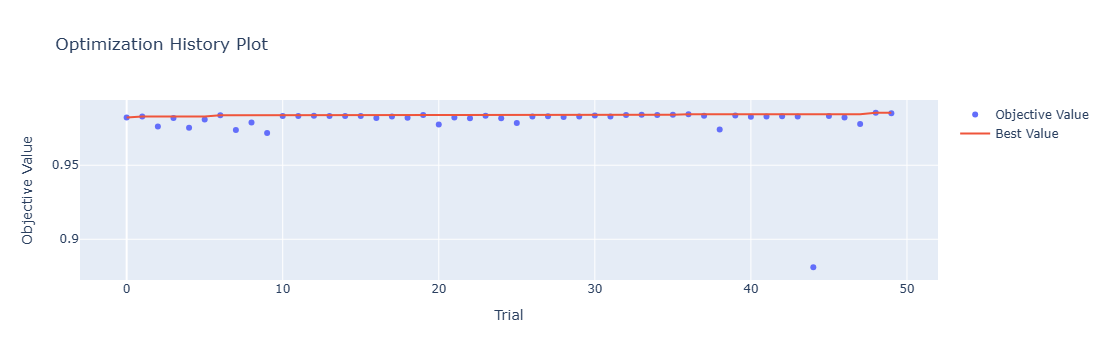

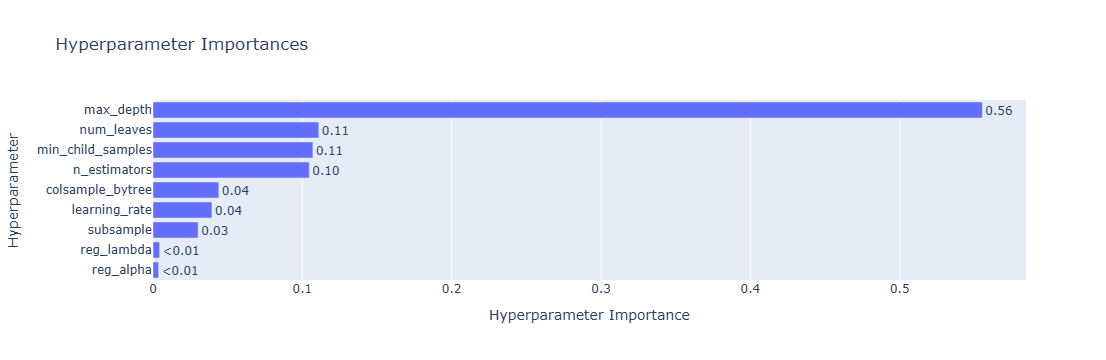

In [5]:
# Plot optimization history
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

# Plot parameter importances
fig2 = optuna.visualization.plot_param_importances(study)
fig2.show()

### Train Final Tuned Model & Log to MLflow

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

best_params = study.best_params
best_params['scale_pos_weight'] = scale
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

mlflow.set_experiment("predictive_maintenance")

with mlflow.start_run(run_name="LightGBM_tuned_optuna"):
    
    final_model = LGBMClassifier(**best_params)
    final_model.fit(X_train, y_train)
    
    y_prob = final_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    
    print(f"Tuned LightGBM Results:")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    
    mlflow.log_params(best_params)
    mlflow.log_metrics({'auc': auc, 'f1': f1, 'precision': prec, 'recall': rec})
    mlflow.sklearn.log_model(final_model, "lgbm_tuned_model")
    
    print("\nTuned model logged to MLflow.")

2026/03/01 15:21:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 15:21:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned LightGBM Results:
  ROC-AUC   : 1.0000
  F1 Score  : 0.9946
  Precision : 0.9907
  Recall    : 0.9985

Tuned model logged to MLflow.


### Save Final Model

In [8]:
import joblib
import os

os.makedirs('D:/Projects/predictiq/models', exist_ok=True)

joblib.dump(final_model, 'D:/Projects/predictiq/models/lgbm_final.pkl')
joblib.dump(feature_cols, 'D:/Projects/predictiq/models/feature_cols.pkl')

print("Model saved to D:/Projects/predictiq/models/lgbm_final.pkl")
print("Feature columns saved to D:/Projects/predictiq/models/feature_cols.pkl")
print(f"\nModel expects {len(feature_cols)} features:")
for col in feature_cols:
    print(f"  {col}")

Model saved to D:/Projects/predictiq/models/lgbm_final.pkl
Feature columns saved to D:/Projects/predictiq/models/feature_cols.pkl

Model expects 34 features:
  volt
  rotate
  pressure
  vibration
  volt_mean_3h
  volt_std_3h
  rotate_mean_3h
  rotate_std_3h
  pressure_mean_3h
  pressure_std_3h
  vibration_mean_3h
  vibration_std_3h
  volt_mean_24h
  volt_std_24h
  rotate_mean_24h
  rotate_std_24h
  pressure_mean_24h
  pressure_std_24h
  vibration_mean_24h
  vibration_std_24h
  error_error1
  error_error2
  error_error3
  error_error4
  error_error5
  days_since_comp2
  days_since_comp4
  days_since_comp3
  days_since_comp1
  age
  model_model1
  model_model2
  model_model3
  model_model4
